In [107]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet


# Synthesizing revenues from 4 segments : Activewear, Balanced, Everyday, and Performance.

In [108]:
orders = pd.read_csv('../orders.csv')
order_items = pd.read_csv('../order_items.csv')
products = pd.read_csv('../products.csv')


/var/folders/36/khn_y8zn7qqflczfpst8cbfc0000gn/T/ipykernel_77399/2590573623.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('../order_items.csv')


In [109]:
orders_detail = orders.merge(order_items, on='order_id', how='left').merge(products, on='product_id', how='left')
orders_detail


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_id,quantity,...,discount_amount,promo_id,promo_id_2,product_name,category,segment,size,color,price,cogs
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2400,7,...,0.0,NaN,NaN,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,609,7,...,0.0,NaN,NaN,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,396,3,...,0.0,NaN,NaN,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,635,5,...,0.0,NaN,NaN,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1935,1,...,0.0,NaN,NaN,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign,690,8,...,0.0,NaN,NaN,SaigonFlex UC-55,Streetwear,Everyday,L,red,4598.817231,3100.062695
714665,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral,1995,7,...,0.0,NaN,NaN,UrbanVN UM-02,Streetwear,Balanced,XL,purple,5159.312851,3025.421056
714666,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign,2331,8,...,0.0,NaN,NaN,VietMotion UE-05,Streetwear,Performance,XL,black,7365.661770,6671.816431
714667,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct,1115,5,...,0.0,NaN,NaN,MekongFit RS-03,Outdoor,Premium,XL,purple,4828.925117,4587.478861


In [110]:
orders_detail['order_date'] = pd.to_datetime(orders_detail['order_date'])


In [111]:
orders_detail['total_revenue'] = orders_detail['quantity'] * orders_detail['unit_price']
orders_detail['total_cogs'] = orders_detail['quantity'] * orders_detail['cogs']
orders_detail


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_id,quantity,...,promo_id_2,product_name,category,segment,size,color,price,cogs,total_revenue,total_cogs
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2400,7,...,NaN,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008,7967.54,7376.586059
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,609,7,...,NaN,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231,71163.75,62913.929616
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,396,3,...,NaN,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256,33660.99,30273.036767
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,635,5,...,NaN,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478,53196.25,46027.152390
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1935,1,...,NaN,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357,1597.84,1048.696357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign,690,8,...,NaN,SaigonFlex UC-55,Streetwear,Everyday,L,red,4598.817231,3100.062695,35791.36,24800.501564
714665,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral,1995,7,...,NaN,UrbanVN UM-02,Streetwear,Balanced,XL,purple,5159.312851,3025.421056,36755.53,21177.947390
714666,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign,2331,8,...,NaN,VietMotion UE-05,Streetwear,Performance,XL,black,7365.661770,6671.816431,59112.48,53374.531451
714667,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct,1115,5,...,NaN,MekongFit RS-03,Outdoor,Premium,XL,purple,4828.925117,4587.478861,23836.65,22937.394304


In [112]:
orders_detail['gross_profit'] = orders_detail['total_revenue'] - orders_detail['total_cogs']


In [113]:
agg = orders_detail.groupby(['order_date','segment'])['gross_profit'].sum().reset_index()


In [114]:
agg


,order_date,segment,gross_profit
0,2012-07-04,Activewear,55252.078596
1,2012-07-04,All-weather,20585.647664
2,2012-07-04,Balanced,393230.115130
3,2012-07-04,Everyday,560146.404186
4,2012-07-04,Performance,76975.533945
...,...,...,...
29888,2022-12-31,Everyday,15418.872376
29889,2022-12-31,Performance,-4253.030962
29890,2022-12-31,Premium,-4101.689545
29891,2022-12-31,Standard,753.933938


In [115]:
agg = agg[agg['segment'].isin(['Activewear', 'Balanced', 'Everyday', 'Performance'])]
agg


,order_date,segment,gross_profit
0,2012-07-04,Activewear,55252.078596
2,2012-07-04,Balanced,393230.115130
3,2012-07-04,Everyday,560146.404186
4,2012-07-04,Performance,76975.533945
8,2012-07-05,Activewear,32071.850168
...,...,...,...
29881,2022-12-30,Performance,7343.999851
29885,2022-12-31,Activewear,7952.854414
29887,2022-12-31,Balanced,71074.345637
29888,2022-12-31,Everyday,15418.872376


In [116]:
agg.groupby('segment')['gross_profit'].mean().sort_values(ascending=False)


segment
Everyday       198687.321936
Balanced       171752.313658
Activewear      94945.088481
Performance     73037.562326
Name: gross_profit, dtype: float64

# Gross Profit trends for Activewear segment

16:32:05 - cmdstanpy - INFO - Chain [1] start processing



Segment: Activewear


16:32:05 - cmdstanpy - INFO - Chain [1] done processing


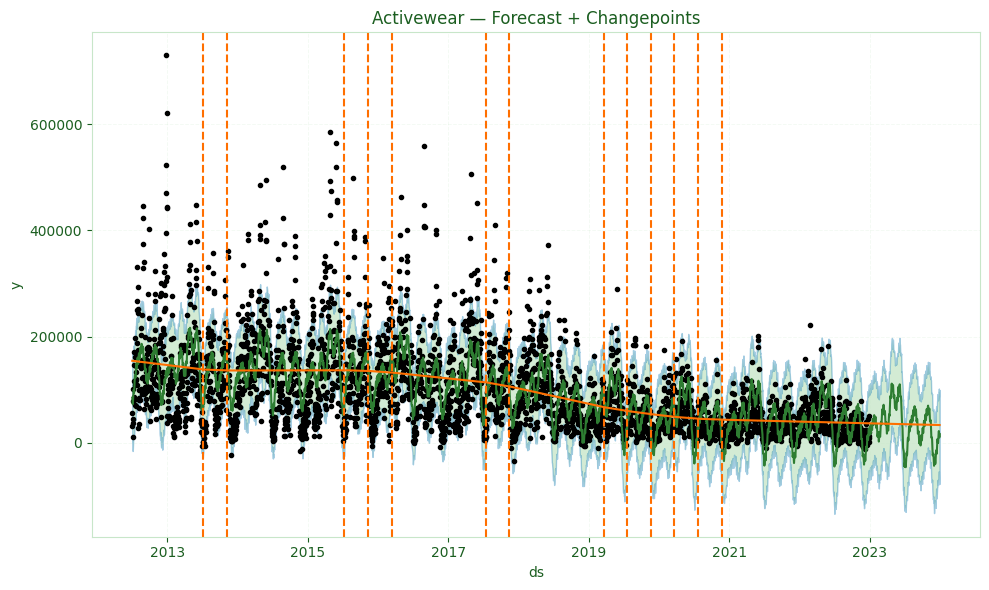

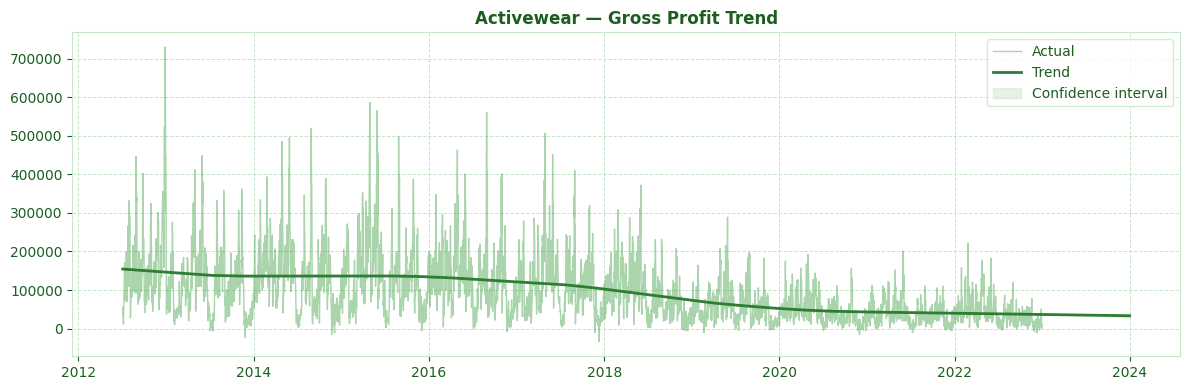

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
16:32:08 - cmdstanpy - INFO - Chain [1] start processing
16:32:08 - cmdstanpy - INFO - Chain [1] start processing
16:32:08 - cmdstanpy - INFO - Chain [1] start processing
16:32:08 - cmdstanpy - INFO - Chain [1] start processing
16:32:08 - cmdstanpy - INFO - Chain [1] start processing
16:32:08 - cmdstanpy - INFO - Chain [1] start processing
16:32:08 - cmdstanpy - INFO - Chain [1] done processing
16:32:08 - cmdstanpy - INFO - Chain [1] done processing
16:32:08 - cmdstanpy - INFO - Chain [1] done processing
16:32:08 - cmdstanpy - INFO - Chain [1] done processing
16:32:08 - cmdstanpy - INFO - Chain [1] done processing
16:32:08 - cmdstanpy - INFO - 

 horizon      mape         rmse          mae
 37 days  2.342547 33314.990744 25325.922105
 38 days  2.105413 33762.419428 25551.270562
 39 days  1.785662 34111.526873 25792.451392
 40 days  1.677997 34058.668025 25639.998632
 41 days  1.649785 33969.901480 25613.522093
 42 days  1.499095 34356.557198 25823.975294
 43 days  1.408051 34649.200361 26120.361049
 44 days  1.382679 37078.056611 27190.988698
 45 days  1.361198 38692.838187 28277.259546
 46 days  1.354554 40507.598818 29342.657000
 47 days  1.351763 41423.260947 29906.123564
 48 days  1.342141 41562.032445 30037.732982
 49 days  1.268239 41740.507368 30270.480398
 50 days  1.206876 42029.422403 30609.351258
 51 days  1.731372 41624.407327 30637.626150
 52 days  1.836206 41278.157517 30570.980017
 53 days  1.843694 41076.168389 30541.340051
 54 days  1.843430 40677.087893 30035.301052
 55 days  1.882257 40588.655307 29913.366993
 56 days  1.908446 40738.359461 30145.117968
 57 days  1.910278 43259.917130 31104.009011
 58 days  

/opt/homebrew/lib/python3.10/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/opt/homebrew/lib/python3.10/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


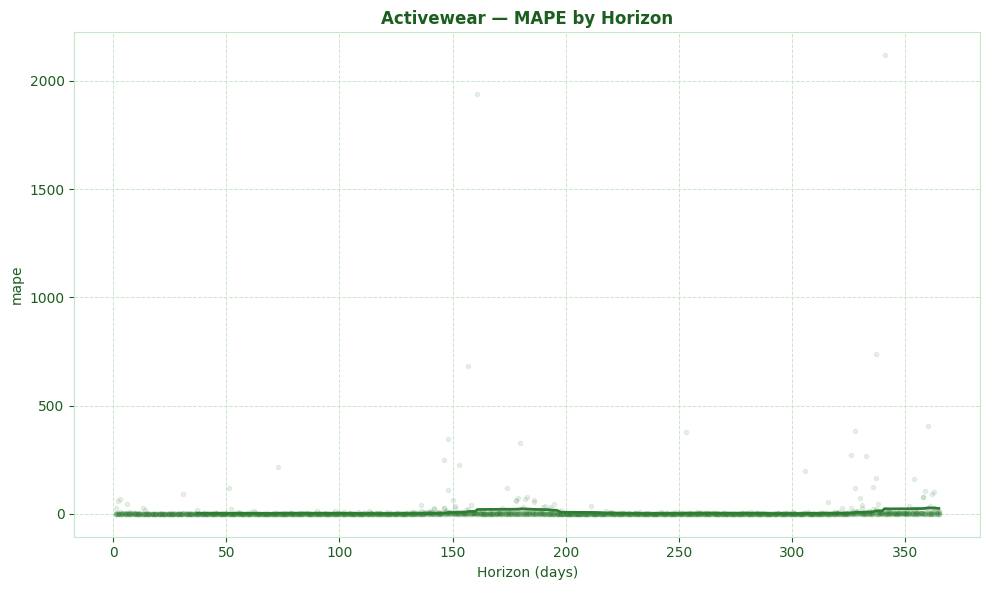

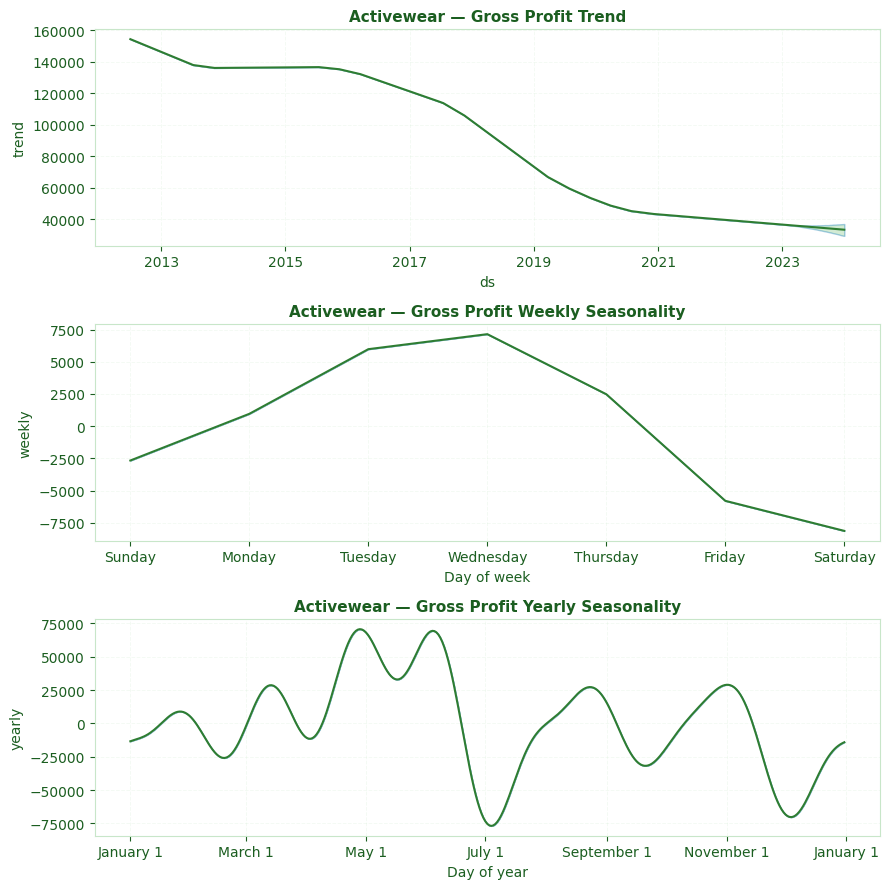

In [124]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric, add_changepoints_to_plot
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Bảng màu xanh lá thống nhất ──────────────────────
GREEN       = '#2e7d32'   # xanh đậm  → đường chính
GREEN_LIGHT = '#81c784'   # xanh nhạt → vùng uncertainty
GREEN_MID   = '#43a047'   # xanh vừa  → actual / accent
BG_COLOR    = '#ffffff'
GRID_COLOR  = '#c8e6c9'   # lưới xanh rất nhạt

def apply_green_theme(fig):
    """Đổi màu toàn bộ axes trong một Prophet figure sang green theme."""
    fig.patch.set_facecolor(BG_COLOR)
    for ax in fig.get_axes():
        ax.set_facecolor(BG_COLOR)
        ax.tick_params(colors='#1b5e20')
        ax.xaxis.label.set_color('#1b5e20')
        ax.yaxis.label.set_color('#1b5e20')
        ax.title.set_color('#1b5e20')
        ax.grid(color=GRID_COLOR, linestyle='--', linewidth=0.7)
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID_COLOR)

        for line in ax.get_lines():
            c = line.get_color()
            # Prophet dùng màu navy/blue cho forecast → đổi sang xanh lá
            if c in ('#0072B2', 'b', 'blue', '#1f77b4', 'steelblue'):
                line.set_color(GREEN)
            # Changepoints thường là đỏ
            elif c in ('r', 'red', '#FF0000'):
                line.set_color('#ff6f00')   # cam để nổi trên nền xanh

        for collection in ax.collections:
            # Vùng confidence interval (uncertainty)
            collection.set_facecolor(GREEN_LIGHT)
            collection.set_alpha(0.35)

# ─────────────────────────────────────────────────────
segments = ['Activewear']

for seg in segments:
    print(f"\n{'='*50}")
    print(f"Segment: {seg}")
    print(f"{'='*50}")

    # ── 1. Chuẩn bị data ──────────────────────────────
    df = (
        agg[agg['segment'] == seg]
        .rename(columns={'order_date': 'ds', 'gross_profit': 'y'})
        [['ds', 'y']]
        .copy()
    )

    # ── 2. Fit model ──────────────────────────────────
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
        n_changepoints=25
    )
    model.fit(df)

    # ── 3. Forecast ───────────────────────────────────
    future = model.make_future_dataframe(periods=365, freq='D')
    forecast = model.predict(future)

    # ── 4. Forecast + Changepoints ────────────────────
    fig = model.plot(forecast)
    add_changepoints_to_plot(fig.gca(), model, forecast)
    apply_green_theme(fig)                          # ← áp green theme
    fig.gca().set_title(f'{seg} — Forecast + Changepoints', color='#1b5e20')
    plt.tight_layout()
    plt.show()

    # ── 4b. Chỉ xem Trend ─────────────────────────────
    fig2, ax = plt.subplots(figsize=(12, 4), facecolor=BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    ax.plot(df['ds'], df['y'],
            label='Actual', alpha=0.45, color=GREEN_MID, linewidth=1)
    ax.plot(forecast['ds'], forecast['trend'],
            label='Trend', color=GREEN, linewidth=2)
    ax.fill_between(
        forecast['ds'],
        forecast['trend_lower'],
        forecast['trend_upper'],
        alpha=0.2, color=GREEN_LIGHT, label='Confidence interval'
    )

    ax.set_title(f'{seg} — Gross Profit Trend', color='#1b5e20', fontweight='bold')
    ax.tick_params(colors='#1b5e20')
    ax.xaxis.label.set_color('#1b5e20')
    ax.yaxis.label.set_color('#1b5e20')
    ax.grid(color=GRID_COLOR, linestyle='--', linewidth=0.7)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COLOR)
    ax.legend(facecolor=BG_COLOR, edgecolor=GRID_COLOR, labelcolor='#1b5e20')

    plt.tight_layout()
    plt.show()

    # ── 5. Cross-validation ───────────────────────────
    df_cv = cross_validation(
        model,
        initial='2555 days',
        period='180 days',
        horizon='365 days',
        parallel='processes'
    )

    # ── 6. Metrics ────────────────────────────────────
    df_metrics = performance_metrics(df_cv)
    print(df_metrics[['horizon', 'mape', 'rmse', 'mae']].to_string(index=False))

    # ── 7. MAPE by Horizon ────────────────────────────
    fig_cv = plot_cross_validation_metric(df_cv, metric='mape')
    apply_green_theme(fig_cv)                       # ← áp green theme
    # MAPE line thường màu xanh dương → đổi lại
    for ax in fig_cv.get_axes():
        for line in ax.get_lines():
            line.set_color(GREEN)
            line.set_linewidth(2)
        ax.set_title(f'{seg} — MAPE by Horizon', color='#1b5e20', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── 8. Components (Trend / Weekly / Yearly) ───────
    fig_comp = model.plot_components(forecast)
    apply_green_theme(fig_comp)

    # Đặt title cho từng subplot
    component_titles = {
        0: f'{seg} — Gross Profit Trend',
        1: f'{seg} — Gross Profit Weekly Seasonality',
        2: f'{seg} — Gross Profit Yearly Seasonality',
    }

    for i, ax in enumerate(fig_comp.get_axes()):
        title = component_titles.get(i, f'{seg} — Component {i+1}')
        ax.set_title(title, color='#1b5e20', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.show()  


In [119]:
df_metrics[['mse','mae','rmse','mape']].mean()


mse     1.722936e+09
mae     3.251967e+04
rmse    4.117562e+04
mape    6.331318e+00
dtype: float64